# Modelo Causal v11 — DAG v2

**Objetivo:** Formalizar o grafo acíclico dirigido (DAG) para as análises causais da configuração v2.


## 1. Imports

In [2]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from app.config.settings import INTERIM_DATA_DIR

import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


## 2. Justificativa das arestas causais

### Confundidores → Tratamentos

| Aresta | Justificativa |
|---|---|
| `customer_state` → atraso | Regiões distantes têm logística mais lenta e mais atrasos |
| `avg_weight` → atraso | Produtos pesados têm manuseio mais complexo e mais sujeitos a atrasos |
| `n_items` → atraso | Pedidos com mais itens têm maior chance de falha na separação |
| `purchase_month` → atraso | Sazonalidade (ex: Black Friday) sobrecarrega a logística |
| `purchase_weekday` → atraso | Compras no fim de semana podem atrasar o despacho |
| `n_items_missing_info` → atraso | Informações faltantes indicam seller problemático |
| `avg_price` → pedido_multi_item | Produtos mais baratos tendem a ser comprados em maior quantidade |
| `avg_weight` → pedido_multi_item | Produtos leves são mais comprados em múltiplas unidades |

### Confundidores → Outcome

| Aresta | Justificativa |
|---|---|
| `customer_state` → score_review | Expectativas e padrão de avaliação variam por região |
| `avg_price` → score_review | Produtos caros geram expectativas maiores |
| `avg_weight` → score_review | Produtos pesados são mais difíceis de receber e inspecionar |
| `purchase_month` → score_review | Sazonalidade afeta 'humor' e expectativa do cliente |

### Tratamentos → Outcome

| Aresta | Justificativa |
|---|---|
| `is_delayed` → score_review | Atraso na entrega gera frustração direta |
| `atraso_leve` → score_review | Atraso leve (1-7d) causa insatisfação moderada |
| `atraso_grave` → score_review | Atraso grave (>7d) causa insatisfação severa |
| `pedido_multi_item` → score_review | Pedidos complexos têm maior chance de erro parcial |

## 3. DAG Geral — todas as variáveis

In [13]:
ARESTAS = [
    # Confundidores → Tratamentos de atraso
    ('customer_state',       'is_delayed'),
    ('customer_state',       'atraso_leve'),
    ('customer_state',       'atraso_grave'),
    ('avg_weight',           'is_delayed'),
    ('avg_weight',           'atraso_leve'),
    ('avg_weight',           'atraso_grave'),
    ('n_items',              'is_delayed'),
    ('n_items',              'atraso_leve'),
    ('n_items',              'atraso_grave'),
    ('purchase_month',       'is_delayed'),
    ('purchase_month',       'atraso_leve'),
    ('purchase_month',       'atraso_grave'),
    ('purchase_weekday',     'is_delayed'),
    ('purchase_weekday',     'atraso_leve'),
    ('purchase_weekday',     'atraso_grave'),
    ('n_items_missing_info', 'is_delayed'),
    ('n_items_missing_info', 'atraso_leve'),
    ('n_items_missing_info', 'atraso_grave'),

    # Confundidores → pedido_multi_item
    ('avg_price',            'pedido_multi_item'),
    ('avg_weight',           'pedido_multi_item'),
    ('purchase_month',       'pedido_multi_item'),
    ('purchase_weekday',     'pedido_multi_item'),
    ('n_items_missing_info', 'pedido_multi_item'),
    ('customer_state',       'pedido_multi_item'),

    # Confundidores → Outcome
    ('customer_state',       'score_review'),
    ('avg_price',            'score_review'),
    ('avg_weight',           'score_review'),
    ('purchase_month',       'score_review'),

    # Tratamentos → Outcome
    ('is_delayed',           'score_review'),
    ('atraso_leve',          'score_review'),
    ('atraso_grave',         'score_review'),
    ('pedido_multi_item',    'score_review'),

    # Relacao hierarquica: atraso_leve e atraso_grave sao subconjuntos de is_delayed
    ('atraso_leve',          'is_delayed'),
    ('atraso_grave',         'is_delayed'),
]

CONFUNDIDORES = ['customer_state', 'avg_price', 'avg_weight', 'n_items',
                 'purchase_month', 'purchase_weekday', 'n_items_missing_info']
TRATAMENTOS   = ['is_delayed', 'atraso_leve', 'atraso_grave', 'pedido_multi_item']
OUTCOMES      = ['score_review']

print(f'Total de arestas:  {len(ARESTAS)}')
print(f'Confundidores:     {len(CONFUNDIDORES)}')
print(f'Tratamentos:       {len(TRATAMENTOS)}')
print(f'Outcomes:          {len(OUTCOMES)}')

Total de arestas:  34
Confundidores:     7
Tratamentos:       4
Outcomes:          1


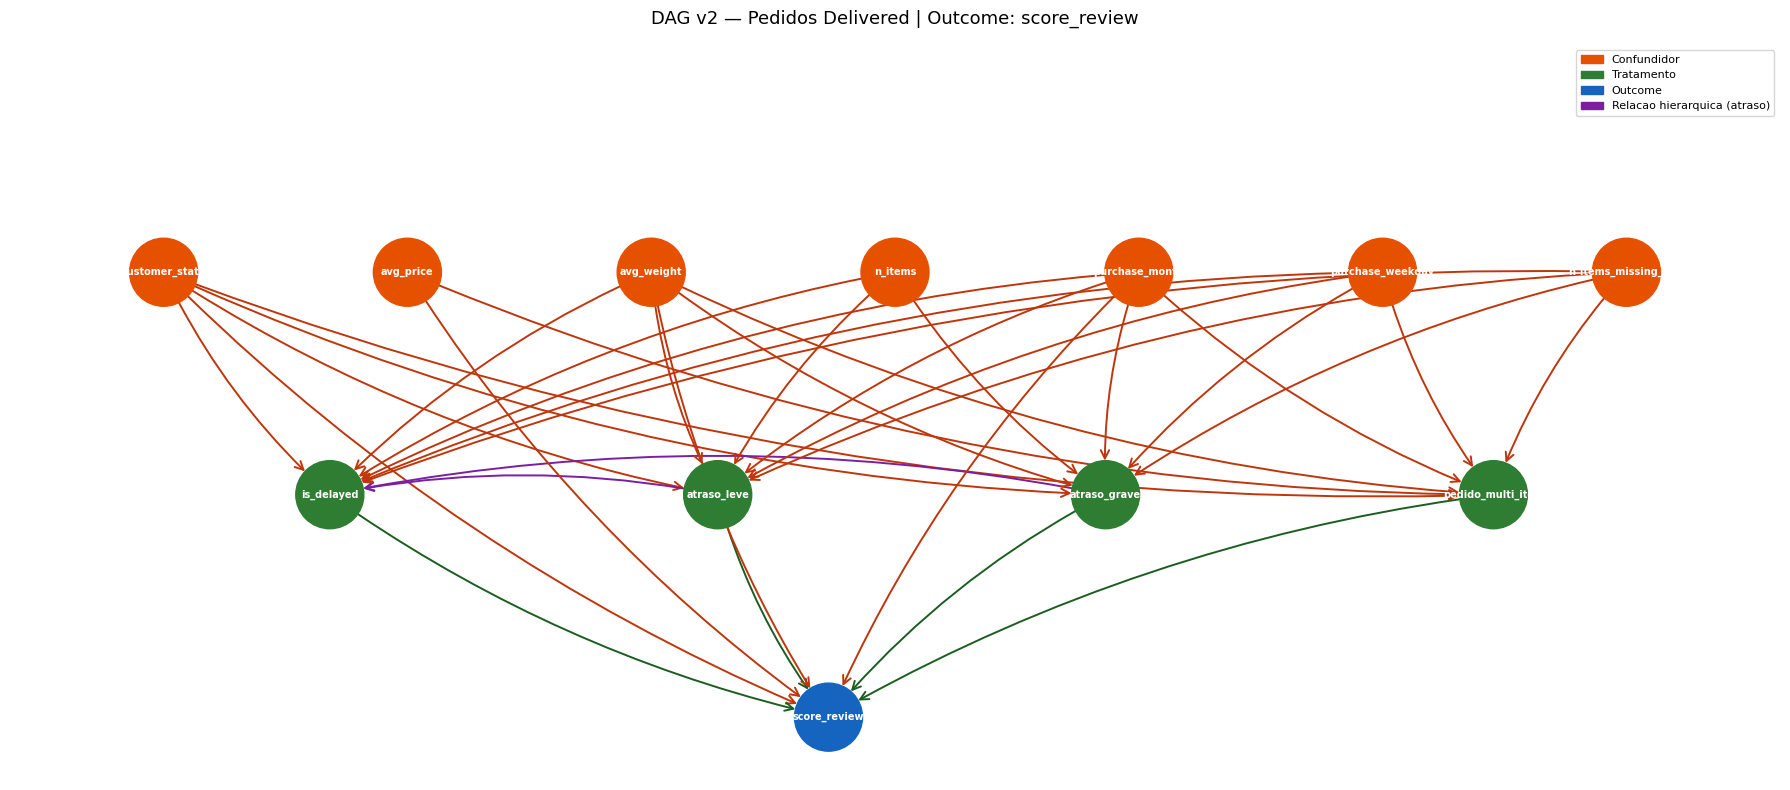

In [4]:
def plot_dag(arestas, confundidores, tratamentos, outcomes,
             titulo='DAG Causal', figsize=(18, 8),
             destaque_t=None, destaque_o=None):
    G = nx.DiGraph()
    G.add_edges_from(arestas)

    # Layout em 3 camadas
    pos = {}
    for i, n in enumerate(confundidores):
        pos[n] = (i * 2.2, 2)
    for i, n in enumerate(tratamentos):
        pos[n] = (i * 3.5 + 1.5, 1)
    for i, n in enumerate(outcomes):
        pos[n] = (i * 6.0 + 6, 0)

    cor_map = {}
    for n in G.nodes():
        if n in outcomes:
            cor_map[n] = '#1565c0'
        elif n in tratamentos:
            cor_map[n] = '#2e7d32' if (destaque_t is None or n == destaque_t) else '#a5d6a7'
        else:
            cor_map[n] = '#e65100'

    cores = [cor_map.get(n, 'gray') for n in G.nodes()]

    edge_colors = []
    for u, v in G.edges():
        if u in tratamentos and v in outcomes:
            edge_colors.append('#1b5e20')
        elif u in tratamentos and v in tratamentos:
            edge_colors.append('#7b1fa2')
        elif u in confundidores:
            edge_colors.append('#bf360c')
        else:
            edge_colors.append('#455a64')

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_color=cores, node_size=2400,
        font_size=7, font_color='white', font_weight='bold',
        edge_color=edge_colors, arrows=True,
        arrowsize=15, arrowstyle='->',
        connectionstyle='arc3,rad=0.1',
        width=1.4
    )

    legend = [
        mpatches.Patch(color='#e65100', label='Confundidor'),
        mpatches.Patch(color='#2e7d32', label='Tratamento'),
        mpatches.Patch(color='#1565c0', label='Outcome'),
        mpatches.Patch(color='#7b1fa2', label='Relacao hierarquica (atraso)'),
    ]
    ax.legend(handles=legend, loc='upper right', fontsize=8)
    ax.set_title(titulo, fontsize=13, pad=15)
    ax.axis('off')
    plt.tight_layout()
    return fig

fig = plot_dag(ARESTAS, CONFUNDIDORES, TRATAMENTOS, OUTCOMES,
               titulo='DAG v2 — Pedidos Delivered | Outcome: score_review')
plt.savefig('../../reports/figures/dag_v2_geral.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 4. DAG por tratamento — critério de backdoor

O **critério de backdoor** identifica o conjunto mínimo de variáveis que, ao serem controladas,
bloqueiam todos os caminhos de backdoor entre tratamento e outcome — permitindo identificação causal.

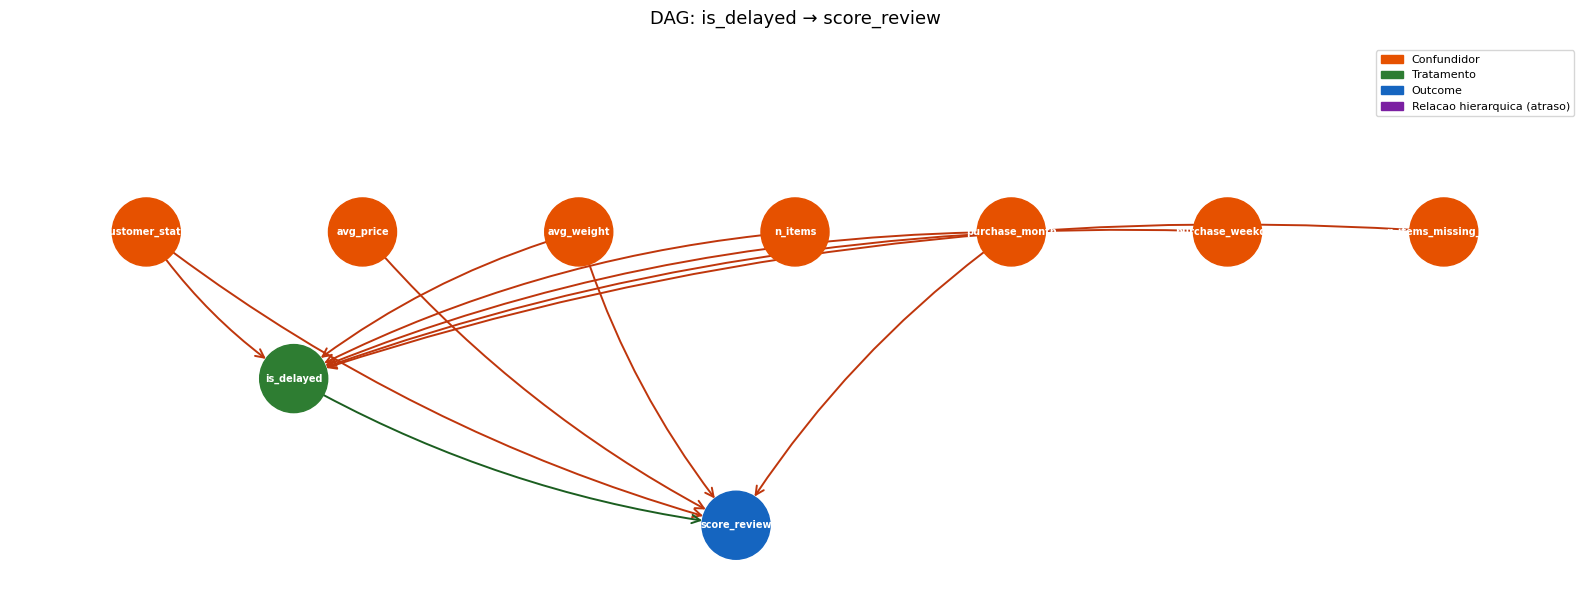

In [5]:
# DAG por tratamento: is_delayed
ARESTAS_DELAY = [
    ('customer_state',       'is_delayed'),
    ('avg_weight',           'is_delayed'),
    ('n_items',              'is_delayed'),
    ('purchase_month',       'is_delayed'),
    ('purchase_weekday',     'is_delayed'),
    ('n_items_missing_info', 'is_delayed'),
    ('customer_state',       'score_review'),
    ('avg_price',            'score_review'),
    ('avg_weight',           'score_review'),
    ('purchase_month',       'score_review'),
    ('is_delayed',           'score_review'),
]
CONF_DELAY = ['customer_state', 'avg_price', 'avg_weight', 'n_items',
              'purchase_month', 'purchase_weekday', 'n_items_missing_info']

fig1 = plot_dag(ARESTAS_DELAY,
                confundidores=CONF_DELAY,
                tratamentos=['is_delayed'],
                outcomes=['score_review'],
                titulo='DAG: is_delayed → score_review',
                figsize=(16, 6), destaque_t='is_delayed')
plt.savefig('../../reports/figures/dag_v2_is_delayed.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

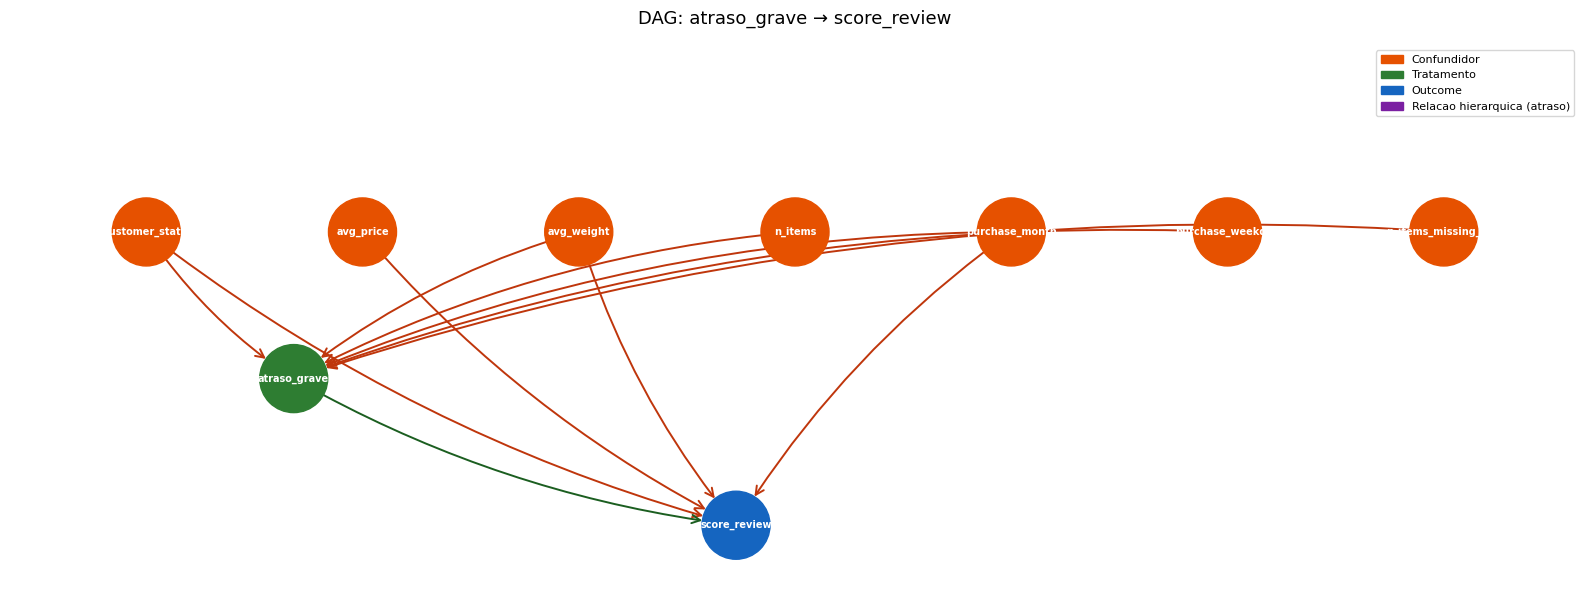

In [6]:
# DAG por tratamento: atraso_grave
ARESTAS_GRAVE = [
    ('customer_state',       'atraso_grave'),
    ('avg_weight',           'atraso_grave'),
    ('n_items',              'atraso_grave'),
    ('purchase_month',       'atraso_grave'),
    ('purchase_weekday',     'atraso_grave'),
    ('n_items_missing_info', 'atraso_grave'),
    ('customer_state',       'score_review'),
    ('avg_price',            'score_review'),
    ('avg_weight',           'score_review'),
    ('purchase_month',       'score_review'),
    ('atraso_grave',         'score_review'),
]

fig2 = plot_dag(ARESTAS_GRAVE,
                confundidores=CONF_DELAY,
                tratamentos=['atraso_grave'],
                outcomes=['score_review'],
                titulo='DAG: atraso_grave → score_review',
                figsize=(16, 6), destaque_t='atraso_grave')
plt.savefig('../../reports/figures/dag_v2_atraso_grave.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

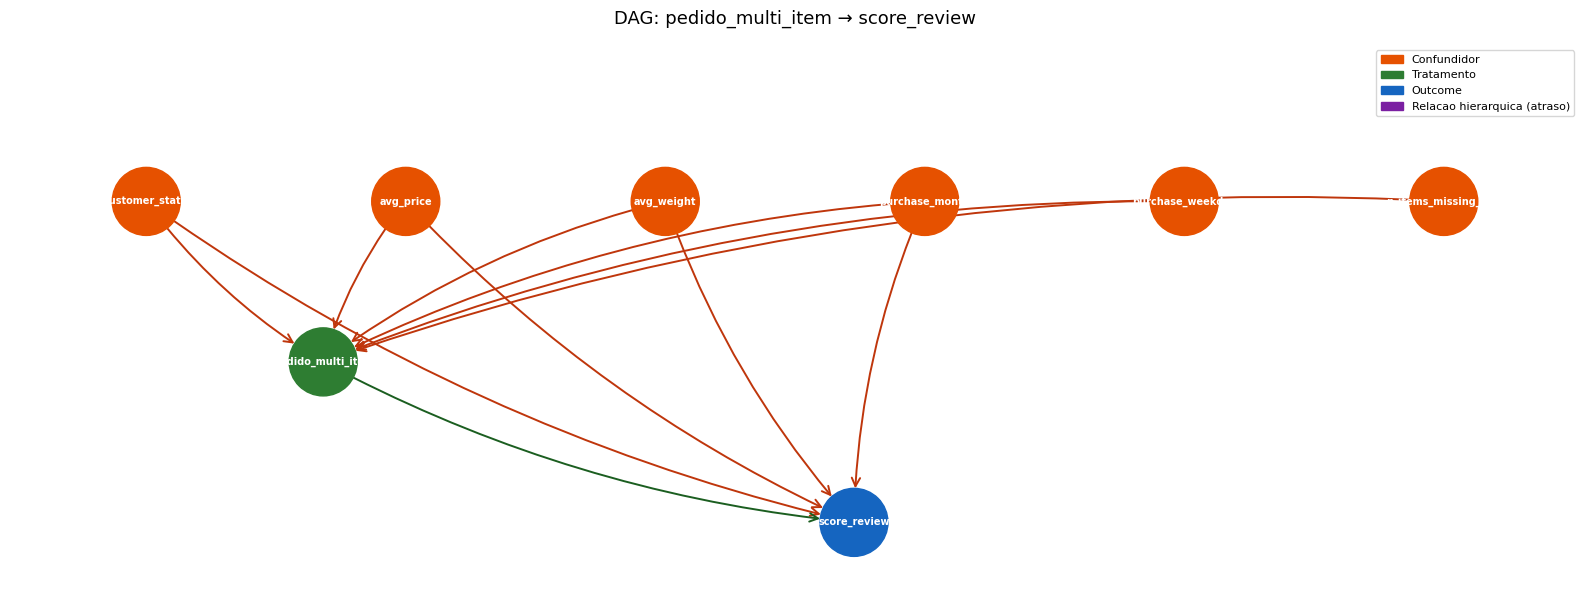

In [7]:
# DAG por tratamento: pedido_multi_item
ARESTAS_PEDIDO = [
    ('customer_state',       'pedido_multi_item'),
    ('avg_price',            'pedido_multi_item'),
    ('avg_weight',           'pedido_multi_item'),
    ('purchase_month',       'pedido_multi_item'),
    ('purchase_weekday',     'pedido_multi_item'),
    ('n_items_missing_info', 'pedido_multi_item'),
    ('customer_state',       'score_review'),
    ('avg_price',            'score_review'),
    ('avg_weight',           'score_review'),
    ('purchase_month',       'score_review'),
    ('pedido_multi_item',    'score_review'),
]
CONF_PEDIDO = ['customer_state', 'avg_price', 'avg_weight',
               'purchase_month', 'purchase_weekday', 'n_items_missing_info']

fig3 = plot_dag(ARESTAS_PEDIDO,
                confundidores=CONF_PEDIDO,
                tratamentos=['pedido_multi_item'],
                outcomes=['score_review'],
                titulo='DAG: pedido_multi_item → score_review',
                figsize=(16, 6), destaque_t='pedido_multi_item')
plt.savefig('../../reports/figures/dag_v2_pedido_multi_item.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 5. Formalização via DoWhy

O DoWhy verifica formalmente se o critério de backdoor é satisfeito para cada par tratamento-outcome,
dado o conjunto de confundidores especificado.

In [8]:
import dowhy
from dowhy import CausalModel

df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'interim_dataset.parquet'))
df = df[df['order_status'] == 'delivered'].copy()
df['pedido_multi_item'] = (df['n_items'] > 1).astype(int)
print(f'Dataset: {df.shape[0]:,} pedidos delivered')

def build_gml(treatment, outcome, confundidores, arestas_extras=None):
    nos = confundidores + [treatment, outcome]
    arestas = [(c, treatment) for c in confundidores] + \
              [(c, outcome)   for c in confundidores] + \
              [(treatment, outcome)]
    if arestas_extras:
        arestas += arestas_extras
    lines = ['graph [directed 1']
    for no in set(nos):
        lines.append(f'  node [ id "{no}" label "{no}" ]')
    for u, v in arestas:
        lines.append(f'  edge [ source "{u}" target "{v}" ]')
    lines.append(']')
    return '\n'.join(lines)

def run_dowhy(df, treatment, outcome, confundidores, nome):
    print(f'\n{"-"*50}')
    print(f'DoWhy: {nome}  ({treatment} -> {outcome})')
    cols = confundidores + [treatment, outcome]
    df_m = df[cols].dropna().copy()
    gml  = build_gml(treatment, outcome, confundidores)
    model = CausalModel(data=df_m, treatment=treatment,
                        outcome=outcome, graph=gml)
    identified = model.identify_effect(proceed_when_unidentifiable=True)
    print(identified)
    return model, identified

print('Funcoes DoWhy definidas.')

Dataset: 95,832 pedidos delivered
Funcoes DoWhy definidas.


In [9]:
# DoWhy — is_delayed → score_review
model_1, id_1 = run_dowhy(
    df, 'is_delayed', 'score_review', CONF_DELAY, 'is_delayed'
)


--------------------------------------------------
DoWhy: is_delayed  (is_delayed -> score_review)
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                                        ↪
─────────────(E[score_⟨review|⟩_weight,n_items_missing_info,purchase_weekday,p ↪
d[is_delayed]                                                                  ↪

↪                                                
↪ urchase_⟨month,⟩_price,customer_state,n_items])
↪                                                
Estimand assumption 1, Unconfoundedness: If U→{is_delayed} and U→score_review then P(score_review|is_delayed,avg_weight,n_items_missing_info,purchase_weekday,purchase_month,avg_price,customer_state,n_items,U) = P(score_review|is_delayed,avg_weight,n_items_missing_info,purchase_weekday,purchase_month,avg_price,customer_state,n_items)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

In [10]:
# DoWhy — atraso_grave → score_review
model_2, id_2 = run_dowhy(
    df, 'atraso_grave', 'score_review', CONF_DELAY, 'atraso_grave'
)


--------------------------------------------------
DoWhy: atraso_grave  (atraso_grave -> score_review)
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
───────────────(E[score_⟨review|⟩_weight,n_items_missing_info,purchase_weekday ↪
d[atraso_grave]                                                                ↪

↪                                                  
↪ ,purchase_⟨month,⟩_price,customer_state,n_items])
↪                                                  
Estimand assumption 1, Unconfoundedness: If U→{atraso_grave} and U→score_review then P(score_review|atraso_grave,avg_weight,n_items_missing_info,purchase_weekday,purchase_month,avg_price,customer_state,n_items,U) = P(score_review|atraso_grave,avg_weight,n_items_missing_info,purchase_weekday,purchase_month,avg_price,customer_state,n_items)

### Estimand : 2
Estimand name: iv
No such va

In [11]:
# DoWhy — pedido_multi_item → score_review
model_3, id_3 = run_dowhy(
    df, 'pedido_multi_item', 'score_review', CONF_PEDIDO, 'pedido_multi_item'
)


--------------------------------------------------
DoWhy: pedido_multi_item  (pedido_multi_item -> score_review)
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                                     ↪
───────────────────(E[score_⟨review|⟩_weight,n_items_missing_info,purchase_wee ↪
d[pedidoₘᵤₗₜᵢ ᵢₜₑₘ]                                                            ↪

↪                                              
↪ kday,purchase_⟨month,⟩_price,customer_state])
↪                                              
Estimand assumption 1, Unconfoundedness: If U→{pedido_multi_item} and U→score_review then P(score_review|pedido_multi_item,avg_weight,n_items_missing_info,purchase_weekday,purchase_month,avg_price,customer_state,U) = P(score_review|pedido_multi_item,avg_weight,n_items_missing_info,purchase_weekday,purchase_month,avg_price,customer_state)

### Estimand : 2
Estimand name: iv
No such varia

## 6. Resumo — Conjuntos de ajuste por tratamento

In [12]:
resumo = [
    {
        'Tratamento':    'is_delayed',
        'Outcome':       'score_review',
        'Confundidores': ', '.join(CONF_DELAY),
        'Excluidos':     'delay_days (base do tratamento)',
        'Backdoor OK?':  'Sim (DoWhy confirmado)',
    },
    {
        'Tratamento':    'atraso_leve',
        'Outcome':       'score_review',
        'Confundidores': ', '.join(CONF_DELAY),
        'Excluidos':     'delay_days (base do tratamento)',
        'Backdoor OK?':  'Sim (mesma estrutura de is_delayed)',
    },
    {
        'Tratamento':    'atraso_grave',
        'Outcome':       'score_review',
        'Confundidores': ', '.join(CONF_DELAY),
        'Excluidos':     'delay_days (base do tratamento)',
        'Backdoor OK?':  'Sim (DoWhy confirmado)',
    },
    {
        'Tratamento':    'pedido_multi_item',
        'Outcome':       'score_review',
        'Confundidores': ', '.join(CONF_PEDIDO),
        'Excluidos':     'n_items (base do tratamento)',
        'Backdoor OK?':  'Sim (DoWhy confirmado)',
    },
]

df_resumo = pd.DataFrame(resumo)
print('Resumo dos conjuntos de ajuste — DAG v2')
print(df_resumo[['Tratamento','Outcome','Backdoor OK?','Excluidos']].to_string(index=False))

Resumo dos conjuntos de ajuste — DAG v2
       Tratamento      Outcome                        Backdoor OK?                       Excluidos
       is_delayed score_review              Sim (DoWhy confirmado) delay_days (base do tratamento)
      atraso_leve score_review Sim (mesma estrutura de is_delayed) delay_days (base do tratamento)
     atraso_grave score_review              Sim (DoWhy confirmado) delay_days (base do tratamento)
pedido_multi_item score_review              Sim (DoWhy confirmado)    n_items (base do tratamento)


## 7. Interpretação
Objetivo do DAG                                                                                                
1. O DAG não é uma análise estatística — ele é a fundamentação teórica que justifica por que as análises do (IPTW e RDD) podem ser interpretadas como causais e não apenas correlacionais. 

2. Declara as suposições causais explicitamente                                                 
  Toda análise causal exige suposições que não podem ser testadas nos dados. O DAG torna essas suposições visíveis e debatíveis:  exemplos:                                                                                                            
  - "Acredito que customer_state afeta tanto o atraso quanto a avaliação"
  - "Acredito que não existe uma variável escondida U que afete simultaneamente o atraso e a nota"                                                                                                                                     


 ## DAG Geral

  resultado satisfatorio . O DoWhy confirmou o critério de backdoor para todos os tratamentos. 

- 95.832 pedidos delivered, 34 arestas, estrutura em 3 camadas  
- Hierarquia entre tratamentos de atraso: atraso_leve e atraso_grave são subconjuntos de is_delayed (arestas roxas no DAG)  

---

## Critério de backdoor — satisfeito para todos os tratamentos

| Tratamento          | Confundidores ajustados | Excluído             |
|---------------------|------------------------|----------------------|
| is_delayed          | 7 variáveis            | delay_days (M-bias)  |
| atraso_leve         | 7 variáveis            | delay_days           |
| atraso_grave        | 7 variáveis            | delay_days           |
| pedido_multi_item   | 6 variáveis            | n_items              |

---

## DoWhy — confirmação formal

- Os 3 tratamentos testados: backdoor identificado com estimando ATE
                                                                                                                                                                                                                   
  ▎ "O DAG v2 estrutura 95.832 pedidos em três camadas causais: 7 confundidores, 4 tratamentos e 1 outcome. O DoWhy confirmou que o ATE é identificável via critério de backdoor para is_delayed, atraso_grave e pedido_multi_item. Nenhuma 
  ▎ variável instrumental ou caminho frontdoor foi encontrado, indicando que o IPTW é o método de identificação adequado."